### **Influencia** de la **intensidad terapéutica**

En esta simulación se estudia cómo afecta la intensidad del tratamiento a la evolución tumoral utilizando el modelo simplificado con concentración constante de fármaco.

Se consideran distintos valores del parámetro

$$
\beta \in {0.0,;0.2,;0.5,;0.8},
$$

donde (\beta=0) corresponde al caso sin tratamiento y valores mayores representan una acción citotóxica más intensa sobre las células tumorales.

Para cada escenario se calcula la evolución temporal de la masa tumoral total,

$$
M(t)=\int_{\Omega} c(x,y,t) \, dx \, dy,
$$

y se compara la eficacia relativa del tratamiento respecto al caso de control. El objetivo es analizar cómo la intensidad terapéutica modifica el crecimiento tumoral y cuantificar la reducción de masa obtenida al aumentar la concentración del fármaco.


Resultados en: C:\Users\fatim\Desktop\TFM_Influencia_Beta
Simulando beta = 0.0


100%|██████████| 150000/150000 [00:46<00:00, 3222.87it/s]


Simulando beta = 0.2


100%|██████████| 150000/150000 [00:44<00:00, 3337.96it/s]


Simulando beta = 0.5


100%|██████████| 150000/150000 [00:46<00:00, 3258.26it/s]


Simulando beta = 0.8


100%|██████████| 150000/150000 [00:46<00:00, 3206.18it/s]


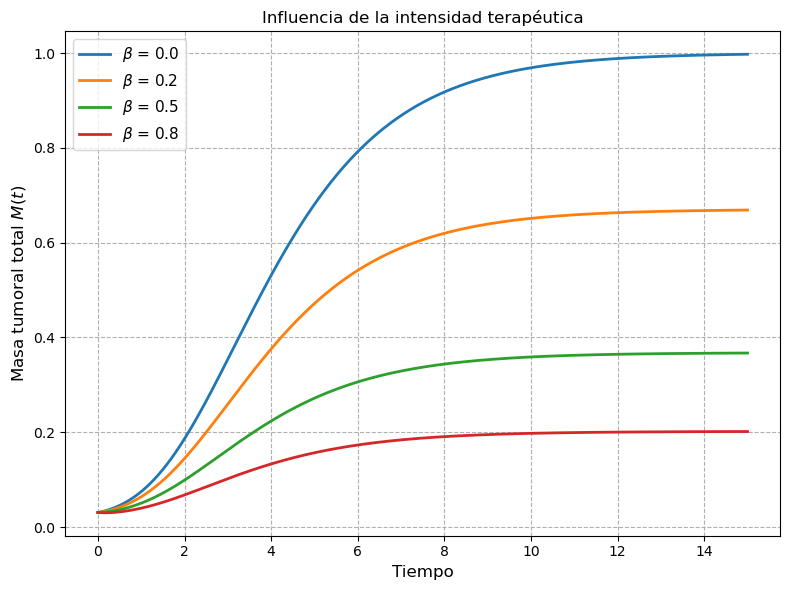

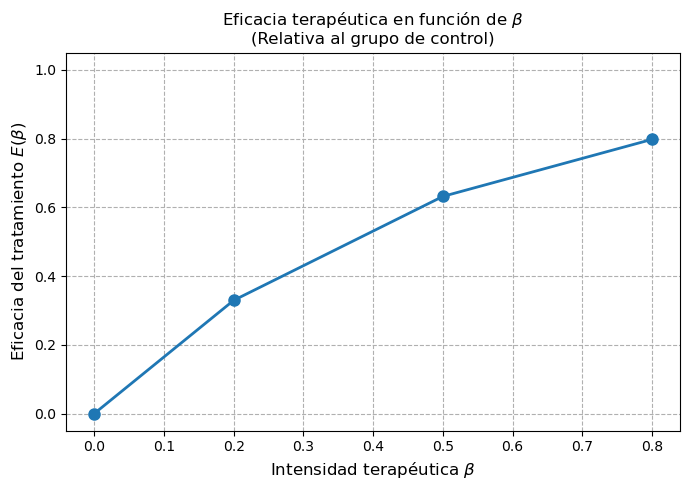


Simulación de sensibilidad a beta finalizada correctamente.


In [2]:
# =====================================================
# LIBRERÍAS
# =====================================================
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# =====================================================
# CREAR CARPETA EN EL ESCRITORIO
# =====================================================
ruta_escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
ruta_figuras = os.path.join(ruta_escritorio, "TFM_Influencia_Beta")

os.makedirs(ruta_figuras, exist_ok=True)

print(f"Resultados en: {ruta_figuras}")

# =====================================================
# PARÁMETROS FIJOS
# =====================================================
D = 0.01  # Difusión tumoral
a = 0.5   # Proliferación celular
K = 1.0   # Capacidad de carga

betas = [0.0, 0.2, 0.5, 0.8]

# =====================================================
# DOMINIO ESPACIAL
# =====================================================
Lx, Ly = 1.0, 1.0
Nx, Ny = 100, 100
dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)

X, Y = np.meshgrid(x, y, indexing="ij")

# =====================================================
# DISCRETIZACIÓN TEMPORAL
# =====================================================
T = 15.0
dt = 1e-4
Nt = int(T / dt)

# =====================================================
# CONDICIÓN INICIAL
# =====================================================
x0, y0 = 0.5, 0.5
sigma = 0.10
c0 = 1.0

# Operador Laplaciano aproximado por diferencias finitas (contorno periódico)
def laplaciano(Z):
    return (np.roll(Z, -1, axis=0) - 2 * Z + np.roll(Z, 1, axis=0)) / dx**2 + (
        np.roll(Z, -1, axis=1) - 2 * Z + np.roll(Z, 1, axis=1)
    ) / dy**2

# =====================================================
# SIMULACIÓN PARAMÉTRICA
# =====================================================
resultados = {}
eficiencia_relativa = {}

# Fase 1: Ejecución de las simulaciones numéricas y registro de masas
for beta in betas:
    c = c0 * np.exp(-((X - x0) ** 2 + (Y - y0) ** 2) / sigma**2)
    masa = []

    print(f"Simulando beta = {beta}")

    for n in tqdm(range(Nt)):
        c_old = c.copy()

        lap = laplaciano(c_old)
        reaction = a * c_old * np.log(K / (c_old + 1e-12))
        treatment = beta * c_old

        c = c_old + dt * (D * lap + reaction - treatment)
        c = np.maximum(c, 0)

        masa.append(np.sum(c) * dx * dy)

    resultados[beta] = masa

# =====================================================
# ÍNDICE DE EFICACIA TERAPÉUTICA
# =====================================================
# Registramos la masa al tiempo final T para el grupo de control (beta = 0.0)
M_control_T = resultados[0.0][-1]

# Calculamos el porcentaje de inhibición relativa para cada valor de beta
for beta in betas:
    M_beta_T = resultados[beta][-1]
    eficiencia_relativa[beta] = 1.0 - (M_beta_T / M_control_T)

# =====================================================
# GRÁFICA 1: EVOLUCIÓN DE LA MASA TUMORAL
# =====================================================
plt.figure(figsize=(8, 6))
t = np.linspace(0, T, Nt)

for beta in betas:
    plt.plot(
        t,
        resultados[beta],
        linewidth=2,
        label=f"$\\beta$ = {beta}",
    )

plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Masa tumoral total $M(t)$", fontsize=12)
plt.title("Influencia de la intensidad terapéutica")
plt.grid(True, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, "comparacion_betas.png"), dpi=300)
plt.show()

# =====================================================
# GRÁFICA 2: EFICACIA TERAPEUTICA RELATIVA
# =====================================================
plt.figure(figsize=(7, 5))

# Extraemos los valores de eficacia en el orden correspondiente de la lista 'betas'
valores_eficiencia = [eficiencia_relativa[b] for b in betas]

plt.plot(betas, valores_eficiencia, marker="o", color="tab:blue", linewidth=2, markersize=8)

plt.xlabel("Intensidad terapéutica $\\beta$", fontsize=12)
plt.ylabel("Eficacia del tratamiento $E(\\beta)$", fontsize=12)
plt.title("Eficacia terapéutica en función de $\\beta$\n(Relativa al grupo de control)")
plt.grid(True, linestyle='--')
plt.ylim(-0.05, 1.05) # Acotamos el eje Y entre 0 y 1 para una visualización analítica elegante
plt.tight_layout()
plt.savefig(os.path.join(ruta_figuras, "eficacia_beta.png"), dpi=300)
plt.show()

print("\nSimulación de sensibilidad a beta finalizada correctamente.")